## IMDB MOVIE REVIEW ANALYSIS -1

In [ ]:
%pip install -U pip setuptools wheel
%pip install -U spacy
!python -m spacy download en_core_web_sm

In [1]:
print("its working")

its working


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Embedding,LSTM,Dropout,Normalization,TextVectorization
from keras.preprocessing.sequence import pad_sequences
import re
import nltk
import spacy


In [5]:
df=pd.read_csv("../datasets/imdb_movie_review/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [8]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [10]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [11]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)          # Remove HTML tags
    text = re.sub(r"http\S+", "", text)        # Remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)    # Remove special characters & numbers
    return text

In [12]:
df["clean_review"]=df["review"].apply(clean_text)

In [13]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...


In [18]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [17]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Relanto\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [20]:
def remove_stopwords(text):
    words = text.split()
    words = [
        word
        for word in words
        if word not in stop_words
    ]
    return " ".join(words)

In [21]:
df["clean_review"] = df["clean_review"].apply(remove_stopwords)

In [22]:
nlp = spacy.load("en_core_web_sm")

In [23]:
def lemmatize(text):
    doc = nlp(text)
    return " ".join(
        token.lemma_
        for token in doc
    )

In [24]:
print(lemmatize("chanu is reading books"))

chanu be read book


In [25]:
df["clean_review"] = df["clean_review"].apply(lemmatize)

In [26]:
vectorize_layer = TextVectorization(
    max_tokens=10000,
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    ngrams=None,
    output_mode='int',
    output_sequence_length=200,
    pad_to_max_tokens=False
)

In [27]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mention watch oz episode you ll h...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,think wonderful way spend time hot summer week...
3,Basically there's a family where a little boy ...,negative,basically there s family little boy jake think...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [29]:
X=df["clean_review"]
y=df["sentiment"].map({
    "positive":1,"negative":0
})
y.head()

0    1
1    1
2    1
3    0
4    1
Name: sentiment, dtype: int64

In [43]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [44]:
vectorize_layer.adapt(X_train)

X_train=vectorize_layer(X_train)
X_test=vectorize_layer(X_test)

In [42]:
print(type(X_train))
print(X_train.shape)
print(X_train[:3])
print(X_train.dtype)

<class 'tensorflow.python.framework.ops.EagerTensor'>
(40000, 200)
tf.Tensor(
[[ 438   57 1085  353 1331   69 6989 1248    6   50   70  536  768    2
  1248 1340  287 2311   23  609  768  220 1684   11   94  983  527 1037
    43  620  210  173    1   82  149   43   23 2241    1  505    1    1
   212  959  245   27  272   35 2715 1083 3051    7   20   77   11 1184
     6    1   41   27    8 2373  456  536    1   31    4  341  149  301
  3178 1865   34   30   92  189  103   12   20    1 3533 3653  167  301
    22   54  173 2971    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0  

In [34]:
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint

In [45]:
model = Sequential([
    Embedding(10000, 128),  
    LSTM(128),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

In [46]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [47]:
early_stop = EarlyStopping(

monitor="val_loss",

patience=3,

restore_best_weights=True

)

In [48]:
checkpoint = ModelCheckpoint(

"best_model.keras",

save_best_only=True

)

In [ ]:
history=model.fit(X_train,y_train,epochs=10,validation_split=0.2,batch_size=32,callbacks=[early_stop,checkpoint])

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 162s 160ms/step - accuracy: 0.5107 - loss: 0.6937 - val_accuracy: 0.5161 - val_loss: 0.6911
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 182s 182ms/step - accuracy: 0.5282 - loss: 0.6791 - val_accuracy: 0.5242 - val_loss: 0.6853
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 150s 150ms/step - accuracy: 0.6494 - loss: 0.5913 - val_accuracy: 0.8350 - val_loss: 0.3920
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 104s 104ms/step - accuracy: 0.8815 - loss: 0.3036 - val_accuracy: 0.8696 - val_loss: 0.3185
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 107s 107ms/step - accuracy: 0.9246 - loss: 0.2092 - val_accuracy: 0.8651 - val_loss: 0.3557
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 108s 108ms/step - accuracy: 0.9485 - loss: 0.1509 - val_accuracy: 0.8708 - val_loss: 0.3633
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 107s 107ms/step - accuracy: 0.9688 - loss: 0.1033 - val_accuracy: 0.8644 - val_loss: 0.4363


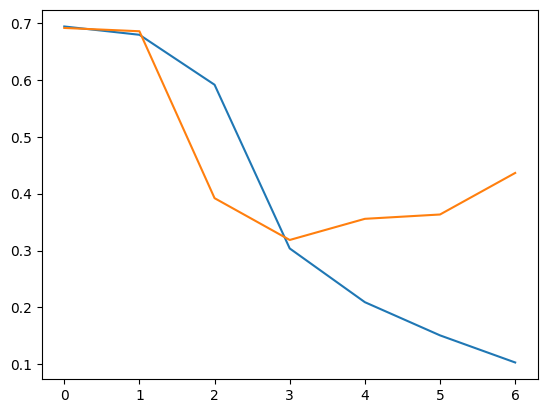

In [50]:
plt.plot(
history.history["loss"]
)

plt.plot(
history.history["val_loss"]
)

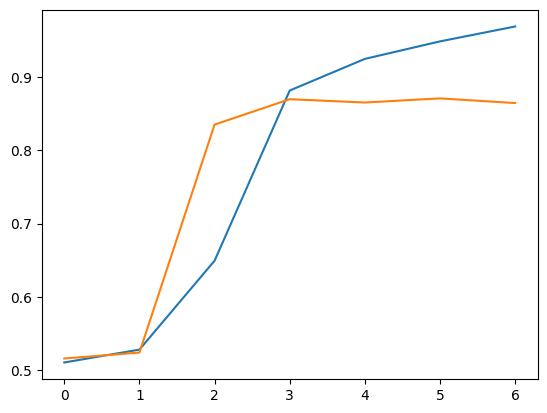

In [53]:
plt.plot(
history.history["accuracy"]
)

plt.plot(
history.history["val_accuracy"]
)

In [54]:
model.evaluate(

X_test,

y_test

)

313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.8698 - loss: 0.3203


[0.32026875019073486, 0.8697999715805054]

In [55]:
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score)

In [56]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step


In [57]:
y_pred = (y_pred > 0.5).astype(int)

In [58]:
print(classification_report(
y_test,
y_pred
))

              precision    recall  f1-score   support

           0       0.88      0.85      0.87      5000
           1       0.86      0.89      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [59]:
cm = confusion_matrix(

y_test,

y_pred

)

<Axes: >

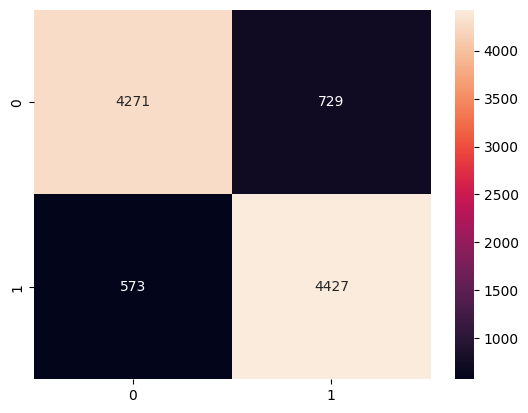

In [60]:
sns.heatmap(

cm,

annot=True,

fmt="d"

)

In [69]:
def predict_review(review):
    # 1. Clean the text using your custom preprocessing
    cleaned_review = clean_text(review)
    cleaned_review = remove_stopwords(cleaned_review)
    cleaned_review = lemmatize(cleaned_review)
    
    # 2. Return a LIST containing the raw processed string
    # This gives it a shape of (1,) which the model expects
    return [cleaned_review]

review = "The movie was absolutely amazing."


In [73]:
print(model.input_shape)
print(type(X_train))
print(X_train.shape)
print(X_train.dtype)

(32, 200)
<class 'tensorflow.python.framework.ops.EagerTensor'>
(40000, 200)
<dtype: 'int64'>


In [75]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (32, 200, 128)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (32, 128)              │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,235,141 (16.16 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,823,428 (10.77 MB)

In [90]:


def predict_movie_review(review):

    review = clean_text(review)
    review = remove_stopwords(review)
    review = lemmatize(review)

    review = tf.constant([review])

    review = vectorize_layer(review)

    prediction = model.predict(review)
    prediction=(prediction>0.5).astype(int)
    prediction="positive" if prediction==1 else "Negative"
    return prediction

In [91]:
review = "one of the very bad climax that i ever saw"
predict_movie_review(review)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


'Negative'